# Who Gets More Attention? Engagement Analysis: Trump vs AOC
## Understanding How Audiences Respond to Political Posts

---

### Why Does Engagement Matter?

In the first notebook, we explored *what* Trump and AOC post and *when* they post it. Now we turn to a different question: **how does the audience respond?**

In traditional political communication -- newspapers, radio, television -- it was very difficult to measure audience response in real time. A politician could give a speech, but had to wait for polls, letters, or election results to know if the message landed. Social media changes this completely. Every tweet generates immediate, measurable feedback: likes, retweets (shares), replies, bookmarks, and views.

This is why engagement analysis is so valuable for studying contemporary political communication. It gives us a window into **how audiences receive and amplify political messages** -- something historians of earlier periods can only dream of having.

In this notebook, we will explore:

1. **Overall engagement** -- Who gets more total attention?
2. **Engagement rate** -- Who is better at turning viewers into participants?
3. **Virality** -- Which tweets spread the furthest, and why?
4. **Content format effects** -- Do photos or videos get more attention?
5. **Timing effects** -- When is the best time to post for maximum response?
6. **Bookmarks** -- Which tweets do people save for later?

---

### Key Terms for This Notebook

- **Engagement**: Any action a viewer takes on a tweet -- liking, retweeting (sharing), replying, quoting, or bookmarking it.
- **Engagement rate = total interactions / views (what percentage of people who saw the tweet actually interacted with it)**: This is the most important metric in this notebook. A tweet seen by 10 million people but liked by only 1,000 has a low engagement rate. A tweet seen by 50,000 people but liked by 5,000 has a much higher one.
- **Virality score**: A measure of how much a tweet was shared (retweeted) relative to how many people saw it. Viral tweets are ones that spread rapidly beyond the original audience.
- **Save rate**: How often people bookmark a tweet for later. This is a quieter, more deliberate form of engagement than a quick "like."
- **Mean (average)**: Add up all the values and divide by the count.
- **Median (the middle value when you sort all numbers)**: Less affected by extreme values than the average.
- **Distribution (how the data is spread across different values)**: Think of it like a bar chart showing where most values fall -- are they clustered together or spread out?

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_tweets
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, comparative_boxplot, comparative_hist,
    format_large_numbers, add_summary_stats
)
from config import FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE, RANDOM_SEED

setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

print('Setup complete.')

Setup complete.


In [2]:
df = load_tweets()

# Quick check
print(f"Shape: {df.shape}")
print(f"Users: {df['user'].value_counts().to_dict()}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

Loaded 200 tweets from processed/
Shape: (200, 42)
Users: {'aoc': 100, 'trump': 100}
Date range: 2025-04-01 20:53:05+00:00 to 2026-02-26 15:32:57+00:00


## 1. The Big Picture: Who Gets More Total Attention?

Let us start with the simplest question: across all 100 tweets we collected for each politician, who received more total likes, retweets, replies, quotes, bookmarks, and views?

Keep in mind that **total numbers** can be misleading. A politician with a much larger following will naturally get more total engagement. That is why we will also look at engagement *rates* (percentages) later. But the totals give us a useful starting point for understanding the sheer scale of audience attention.

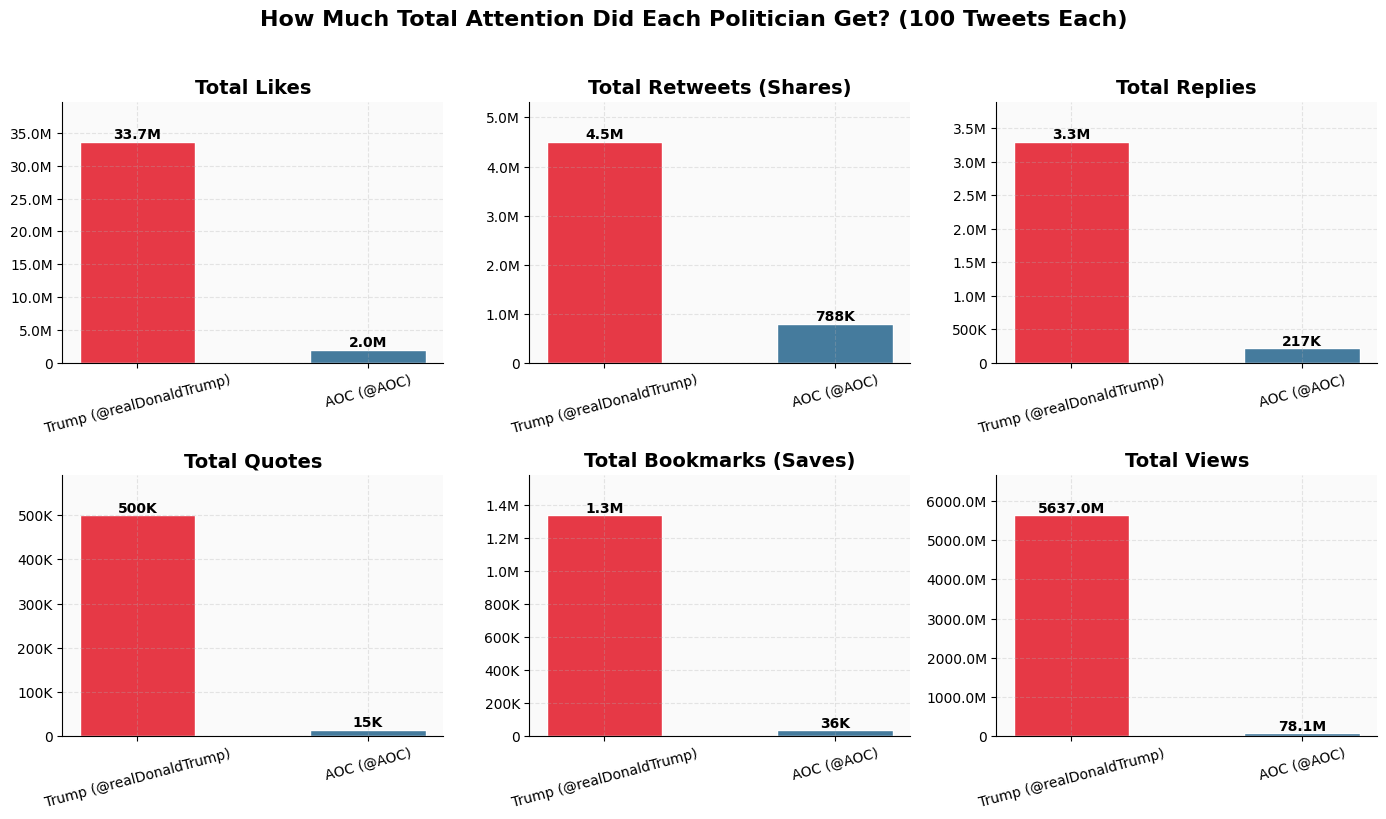

In [3]:
# --- Total Engagement: How Much Attention Did Each Politician Get? ---

engagement_metrics = [
    ('favorite_count', 'Likes'),
    ('retweet_count', 'Retweets (Shares)'),
    ('reply_count', 'Replies'),
    ('quote_count', 'Quotes'),
    ('bookmark_count', 'Bookmarks (Saves)'),
    ('view_count', 'Views'),
]

fig, axes = plt.subplots(2, 3, figsize=FIGURE_SIZE_LARGE)
axes = axes.flatten()

for idx, (metric, label) in enumerate(engagement_metrics):
    ax = axes[idx]
    users = ['trump', 'aoc']
    totals = [df[df['user'] == u][metric].sum() for u in users]
    user_labels = [get_user_label(u) for u in users]
    
    bars = ax.bar(user_labels, totals,
                  color=[colors[u] for u in users],
                  width=0.5, edgecolor='white')
    
    # Add value labels on bars
    for bar, val in zip(bars, totals):
        if val >= 1_000_000:
            display_val = f"{val/1_000_000:.1f}M"
        elif val >= 1_000:
            display_val = f"{val/1_000:.0f}K"
        else:
            display_val = f"{val:,.0f}"
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                display_val, ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    
    ax.set_title(f'Total {label}', fontweight='bold')
    ax.set_ylim(0, max(totals) * 1.18 if max(totals) > 0 else 1)
    format_large_numbers(ax)
    
    # Rotate x-tick labels for readability
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('How Much Total Attention Did Each Politician Get? (100 Tweets Each)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

These six charts show the total number of each type of interaction across all 100 tweets for each politician. The numbers labeled on top of each bar make it easy to compare.

Notice which politician dominates in **views** (raw reach) versus **replies** (active conversation). A politician with high views but relatively lower replies has an audience that mostly watches passively. One with a high reply count relative to views has an audience that actively talks back. Both patterns tell us something about the relationship between the politician and their followers.

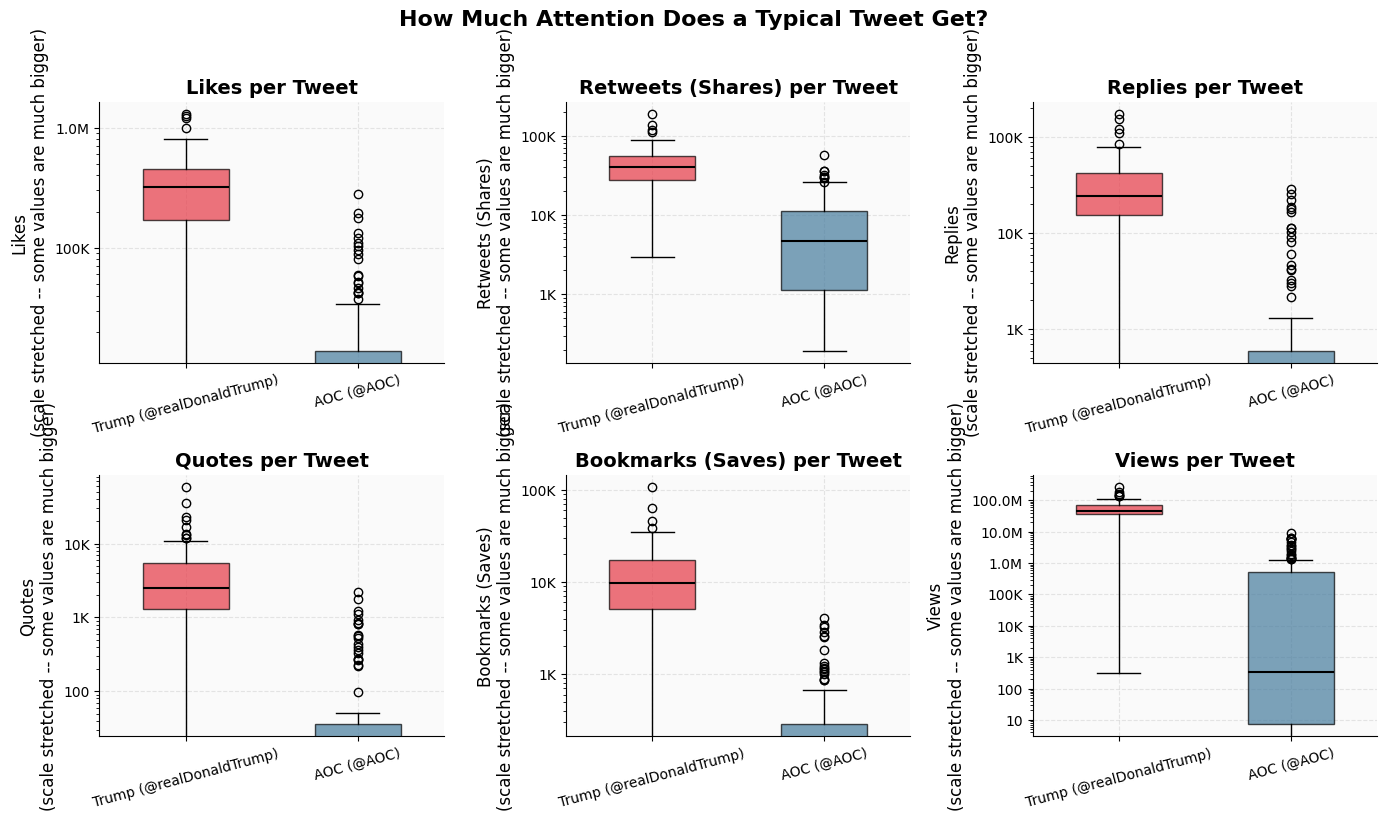

In [4]:
# --- How Much Attention Does a Typical Tweet Get? (Box Plots) ---

fig, axes = plt.subplots(2, 3, figsize=FIGURE_SIZE_LARGE)
axes = axes.flatten()

for idx, (metric, label) in enumerate(engagement_metrics):
    ax = axes[idx]
    users = ['trump', 'aoc']
    data = [df[df['user'] == u][metric].dropna().values for u in users]
    user_labels = [get_user_label(u) for u in users]
    
    bp = ax.boxplot(data, labels=user_labels, patch_artist=True, widths=0.5,
                    medianprops={'color': 'black', 'linewidth': 1.5})
    for patch, user in zip(bp['boxes'], users):
        patch.set_facecolor(colors[user])
        patch.set_alpha(0.7)
    
    ax.set_title(f'{label} per Tweet', fontweight='bold')
    
    # Note: we stretch the scale when some numbers are much bigger than others
    max_val = max(d.max() for d in data if len(d) > 0)
    min_val = min(d[d > 0].min() if len(d[d > 0]) > 0 else 1 for d in data)
    if max_val > 0 and max_val / max(min_val, 1) > 100:
        ax.set_yscale('log')
        ax.set_ylabel(f'{label}\n(scale stretched -- some values are much bigger)')
    else:
        ax.set_ylabel(label)
    
    format_large_numbers(ax)
    ax.tick_params(axis='x', rotation=15)

fig.suptitle('How Much Attention Does a Typical Tweet Get?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

These are called **box plots**. Here is how to read them:

- The **colored box** shows the range where the middle 50% of tweets fall (from the 25th to the 75th percentile)
- The **black line inside the box** is the median (middle value)
- The **lines extending from the box** ("whiskers") show the wider range of typical values
- The **dots beyond the whiskers** are unusual values -- tweets that performed much better or worse than normal

If one politician's box is much higher than the other's, their typical tweet gets more engagement. If one politician has many dots above the whiskers, they have more tweets that performed exceptionally well (viral hits).

*Note: In some charts, we stretched the vertical scale because some numbers are much bigger than others. This makes it easier to see differences, but be aware that the spacing between numbers is not even.*

## 2. Engagement Rate: Who Turns Viewers Into Participants?

Raw numbers (total likes, total retweets) can be misleading because they depend heavily on audience size. A politician with 90 million followers will naturally get more likes than one with 10 million, even if the content is less compelling.

That is why we use the **engagement rate = total interactions / views (what percentage of people who saw the tweet actually interacted with it)**. This levels the playing field by asking: of all the people who *saw* a tweet, what percentage actually *did something* with it?

A high engagement rate means the content resonated strongly with its audience. A low rate means people saw it but mostly scrolled past.

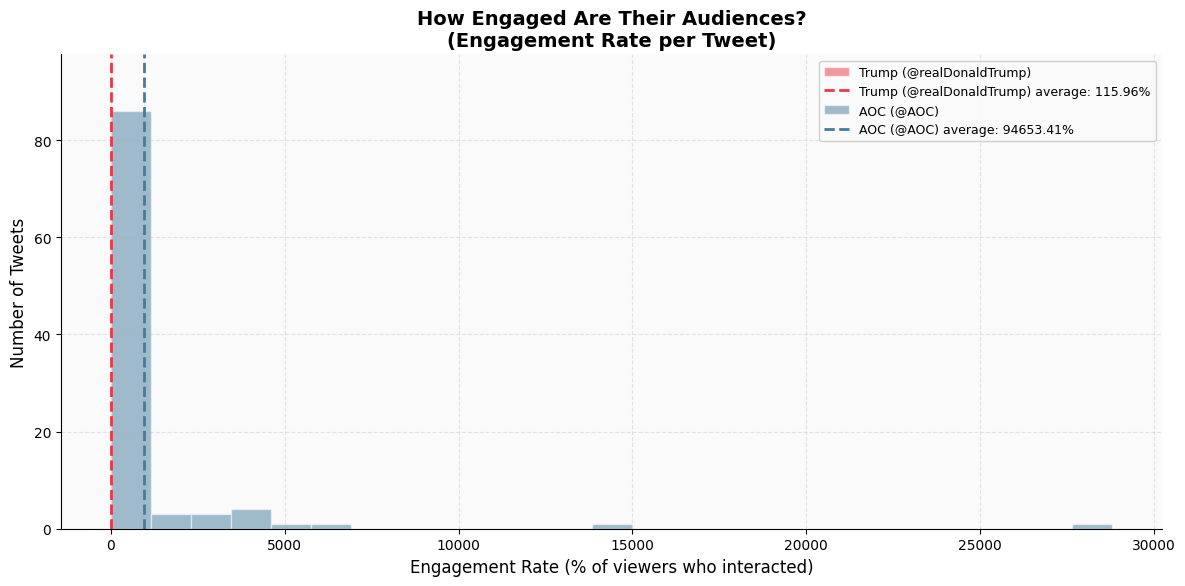

In [5]:
# --- How Engaged Are Their Audiences? (Engagement Rate per Tweet) ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['engagement_rate'].dropna()
    label = get_user_label(user)
    
    ax.hist(user_data, bins=25, alpha=0.5, label=label,
            color=colors[user], edgecolor='white')
    
    # Add average line
    mean_val = user_data.mean()
    ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=2,
               label=f'{label} average: {mean_val:.2%}')

ax.set_title('How Engaged Are Their Audiences?\n(Engagement Rate per Tweet)', fontweight='bold', fontsize=14)
ax.set_xlabel('Engagement Rate (% of viewers who interacted)')
ax.set_ylabel('Number of Tweets')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### What does this tell us?

This chart shows the spread of engagement rates across all tweets for each politician. The dashed lines show the average engagement rate.

If one politician's bars are shifted to the right compared to the other's, it means their tweets consistently convert a higher percentage of viewers into active participants. This is a strong indicator of audience loyalty and content resonance.

Think of it this way: reaching a lot of people is one thing (that depends on follower count and algorithmic promotion), but getting those people to actually *react* is another. The engagement rate tells us about the quality of the connection between politician and audience.

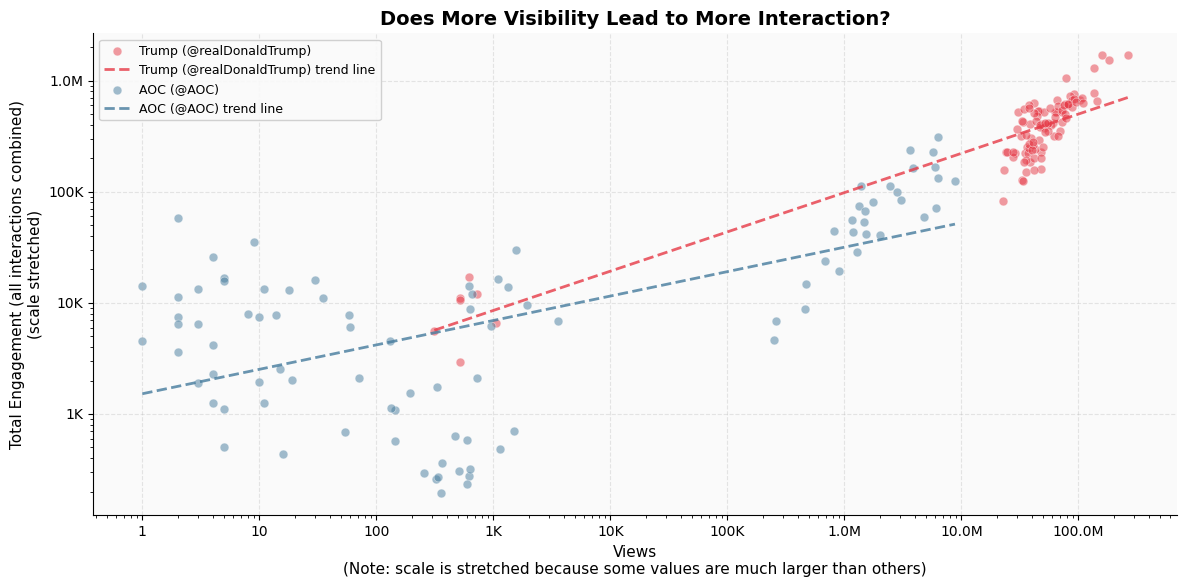

In [6]:
# --- Does More Visibility Lead to More Interaction? (Views vs Total Engagement) ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

for user in ['trump', 'aoc']:
    mask = (df['user'] == user) & (df['view_count'] > 0) & (df['total_engagement'] > 0)
    user_data = df[mask]
    label = get_user_label(user)
    
    ax.scatter(user_data['view_count'], user_data['total_engagement'],
               color=colors[user], alpha=0.5, s=40, label=label, edgecolors='white', linewidth=0.5)
    
    # Trend line (shows the general direction of the relationship)
    log_x = np.log10(user_data['view_count'].values)
    log_y = np.log10(user_data['total_engagement'].values)
    coeffs = np.polyfit(log_x, log_y, 1)
    x_fit = np.linspace(log_x.min(), log_x.max(), 100)
    y_fit = np.polyval(coeffs, x_fit)
    ax.plot(10**x_fit, 10**y_fit, color=colors[user], linestyle='--',
            linewidth=2, alpha=0.8, label=f'{label} trend line')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Views\n(Note: scale is stretched because some values are much larger than others)', fontsize=11)
ax.set_ylabel('Total Engagement (all interactions combined)\n(scale stretched)', fontsize=11)
ax.set_title('Does More Visibility Lead to More Interaction?', fontweight='bold', fontsize=14)
ax.legend(fontsize=9)
format_large_numbers(ax, axis='x')
format_large_numbers(ax, axis='y')
plt.tight_layout()
plt.show()

### What does this tell us?

Each dot represents one tweet. Its position on the horizontal axis shows how many people saw it (views), and its vertical position shows how many interactions it received. The dashed trend line shows the general relationship between visibility and engagement.

If the dots for one politician sit consistently above the other's, it means they get more engagement *for the same number of views* -- their content is more compelling to their audience. If the dots are scattered widely, it means engagement is unpredictable -- some tweets perform much better than others even with similar visibility.

*Note: Both axes are stretched (this is sometimes called a "logarithmic scale") because some tweets get millions of views while others get thousands. Without stretching, all the smaller dots would be crammed into one corner and impossible to read.*

In [7]:
# --- Detailed Engagement Rate Comparison ---

rate_metrics = ['engagement_rate', 'like_rate', 'retweet_rate',
                'reply_rate', 'virality_score', 'save_rate']

stats_data = []
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    row = {'User': get_user_label(user)}
    for metric in rate_metrics:
        col_data = user_df[metric].dropna()
        nice_name = metric.replace('_', ' ').title()
        row[f'{nice_name} (Average)'] = col_data.mean()
        row[f'{nice_name} (Middle Value)'] = col_data.median()
        row[f'{nice_name} (Best Tweet)'] = col_data.max()
    stats_data.append(row)

stats_df = pd.DataFrame(stats_data).set_index('User')

# Format values
def fmt_val(x):
    if abs(x) < 1:
        return f"{x:.4f}"
    return f"{x:.2f}"

styled = stats_df.style.format(fmt_val).set_caption(
    'Engagement Rate Breakdown: Average, Middle Value, and Best Tweet'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold')]}
])

display(styled)

,Engagement Rate (Average),Engagement Rate (Middle Value),Engagement Rate (Best Tweet),Like Rate (Average),Like Rate (Middle Value),Like Rate (Best Tweet),Retweet Rate (Average),Retweet Rate (Middle Value),Retweet Rate (Best Tweet),Reply Rate (Average),Reply Rate (Middle Value),Reply Rate (Best Tweet),Virality Score (Average),Virality Score (Middle Value),Virality Score (Best Tweet),Save Rate (Average),Save Rate (Middle Value),Save Rate (Best Tweet)
User,,,,,,,,,,,,,,,,,,
Trump (@realDonaldTrump),1.16,0.0075,27.53,0.0057,0.0056,0.0146,1.15,0.0008,27.53,0.0005,0.0005,0.0017,1.15,0.0009,27.53,0.0002,0.0002,0.0008
AOC (@AOC),946.53,2.41,28802.50,0.0083,0.0000,0.0758,946.52,2.41,28802.50,0.0007,0.0000,0.0074,946.52,2.41,28802.50,0.0001,0.0000,0.0010


### What does this tell us?

This table breaks down the engagement rate into its components:

- **Engagement Rate**: Overall percentage of viewers who interacted
- **Like Rate**: Percentage of viewers who liked the tweet
- **Retweet Rate**: Percentage of viewers who shared the tweet
- **Reply Rate**: Percentage of viewers who wrote a reply
- **Virality Score**: How much the tweet was shared relative to views
- **Save Rate**: Percentage of viewers who bookmarked the tweet

Each metric tells a different story. High like rates mean passive approval. High retweet rates mean active amplification. High reply rates mean the content provokes conversation. The "Best Tweet" column shows the peak performance -- the single most engaging tweet for each metric.

## 3. Going Viral: Which Tweets Spread the Furthest?

**Virality** -- the rapid, widespread sharing of content -- is one of the most fascinating aspects of digital political communication. A single tweet can reach millions of people within hours, far beyond the politician's own followers.

What makes a tweet go viral? Is it the topic? The wording? The timing? Let us look at the most viral tweets from each politician and see if we can spot patterns.

In [8]:
# --- The 10 Most Viral Tweets for Each Politician ---

for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user].nlargest(10, 'virality_score')
    
    display_df = user_df[['text', 'virality_score', 'favorite_count',
                          'retweet_count', 'view_count']].copy()
    display_df['text'] = display_df['text'].str[:80] + '...'
    display_df = display_df.reset_index(drop=True)
    display_df.index = display_df.index + 1  # 1-based ranking
    display_df.index.name = 'Rank'
    
    # Format numeric columns
    display_df['virality_score'] = display_df['virality_score'].apply(lambda x: f"{x:.4f}")
    display_df['favorite_count'] = display_df['favorite_count'].apply(lambda x: f"{x:,.0f}")
    display_df['retweet_count'] = display_df['retweet_count'].apply(lambda x: f"{x:,.0f}")
    display_df['view_count'] = display_df['view_count'].apply(lambda x: f"{x:,.0f}")
    
    display_df.columns = ['Tweet Text (first 80 characters)', 'Virality Score', 'Likes', 'Retweets', 'Views']
    
    print(f"\n{'='*80}")
    print(f"Top 10 Most Viral Tweets -- {get_user_label(user)}")
    print(f"{'='*80}")
    display(display_df)


Top 10 Most Viral Tweets -- Trump (@realDonaldTrump)


,Tweet Text (first 80 characters),Virality Score,Likes,Retweets,Views
Rank,,,,,
1,RT @kaitrump: I had an amazing time filming wi...,27.5297,0,"17,151",623
2,"RT @DanScavino: On behalf of Erin and me, than...",21.0364,0,"10,981",522
3,"RT @MELANIATRUMP: MELANIA, the film.\n#1 Highe...",20.6680,0,"10,706",518
4,"RT @FoxNews: RECORD BREAKER: “Melania,” a docu...",17.6773,0,"5,533",313
5,RT @johnrich: A conversation about online chil...,16.4822,0,"12,032",730
6,RT @nypost: Democratic Rep. Jasmine Crockett a...,6.2220,0,"6,558","1,054"
7,RT @THR: Box Office: ‘Melania’ Heads for $8 Mi...,5.6130,0,"2,930",522
8,https://t.co/JzQYLShOCt...,0.0022,"460,110","80,916","41,656,800"
9,https://t.co/08KV4EtQDZ...,0.0019,"390,427","55,943","30,443,479"



Top 10 Most Viral Tweets -- AOC (@AOC)


,Tweet Text (first 80 characters),Virality Score,Likes,Retweets,Views
Rank,,,,,
1,RT @PopBase: Bad Bunny closed out his #SuperBo...,28802.5000,0,"57,605",2
2,RT @brianstelter: A statement from the family ...,14259.0000,0,"14,259",1
3,RT @HillaryClinton: So let’s stop the games. \...,6513.2500,0,"26,053",4
4,"RT @atrupar: AOC: ""How rich is it that she is ...",5689.0000,0,"11,378",2
5,RT @WSJ: Exclusive: A U.S. official has allege...,4520.0000,0,"4,520",1
6,RT @IlhanMN: I’m ok. I’m a survivor so this sm...,4434.0000,0,"13,302",3
7,RT @jaketapper: DOJ has since killed this link...,3942.7778,0,"35,485",9
8,RT @RepThomasMassie: 🧵1) This is significant b...,3766.5000,0,"7,533",2
9,RT @RepRaskin: The DOJ is giving Members of Co...,3341.2000,0,"16,706",5


### What does this tell us?

Read through the actual text of the most viral tweets. What topics come up? Are they about policy, personal attacks, cultural commentary, or breaking news? Viral content often taps into strong emotions -- outrage, humor, solidarity, or surprise.

As you read these tweets, think about what a historian 50 years from now would learn about American political culture from these most-shared messages. What issues matter to each politician's audience? What tone resonates most?

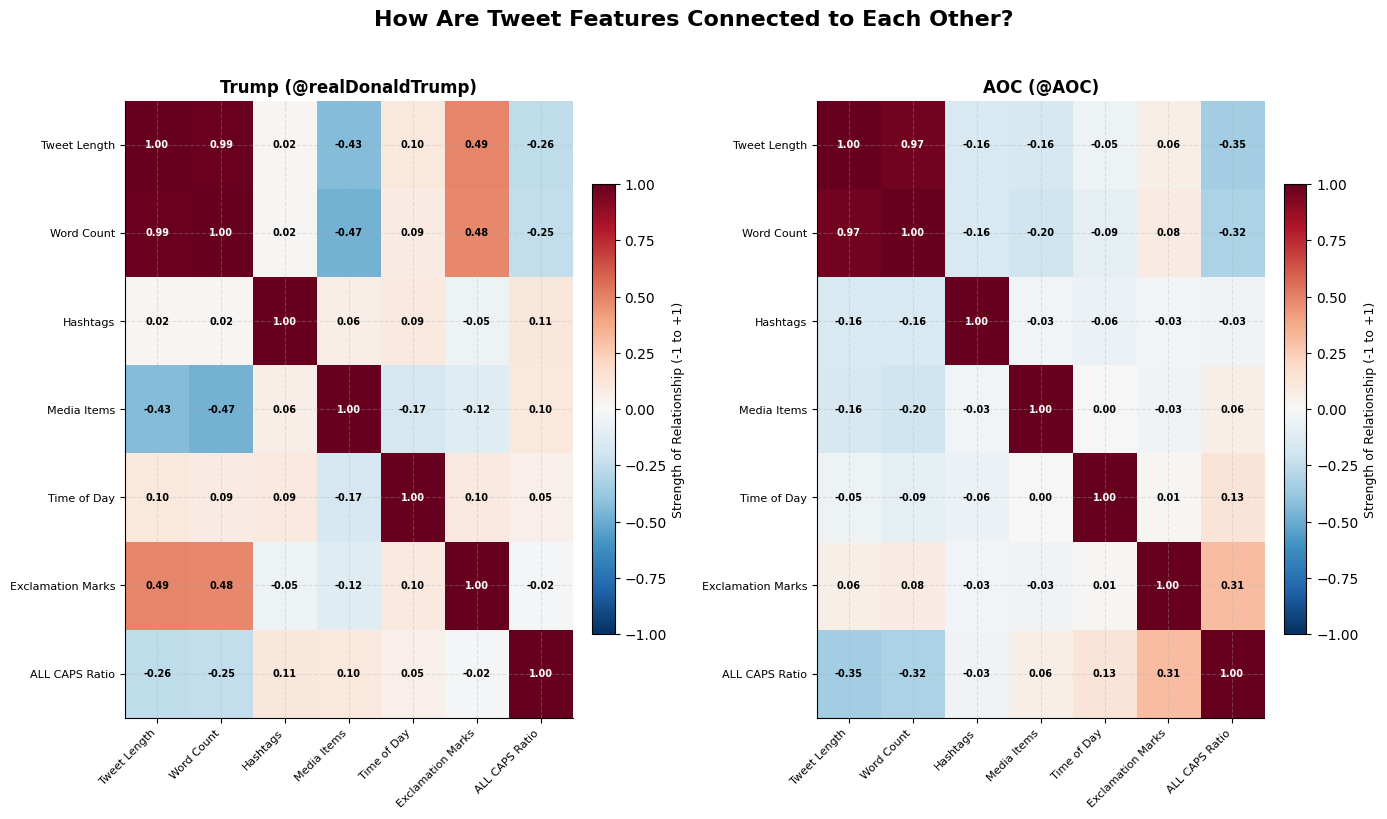

In [9]:
# --- What Tweet Features Are Connected to Higher Engagement? ---

correlation_features = ['text_length', 'word_count', 'hashtag_count',
                        'media_count', 'hour', 'exclamation_count', 'caps_ratio']

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_df = df[df['user'] == user]
    
    # How strongly connected is each feature to the others?
    corr_data = user_df[['engagement_rate'] + correlation_features].corr()
    
    corr_matrix = corr_data.loc[correlation_features, correlation_features]
    
    # Create heatmap
    im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    
    # Set tick labels with plain English names
    feature_labels = {
        'text_length': 'Tweet Length',
        'word_count': 'Word Count',
        'hashtag_count': 'Hashtags',
        'media_count': 'Media Items',
        'hour': 'Time of Day',
        'exclamation_count': 'Exclamation Marks',
        'caps_ratio': 'ALL CAPS Ratio'
    }
    labels = [feature_labels.get(f, f) for f in correlation_features]
    ax.set_xticks(range(len(correlation_features)))
    ax.set_yticks(range(len(correlation_features)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    
    # Add values as text
    for i in range(len(correlation_features)):
        for j in range(len(correlation_features)):
            val = corr_matrix.values[i, j]
            text_color = 'white' if abs(val) > 0.5 else 'black'
            ax.text(j, i, f"{val:.2f}", ha='center', va='center',
                    fontsize=7, color=text_color, fontweight='bold')
    
    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=12)
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Strength of Relationship (-1 to +1)', fontsize=9)

fig.suptitle('How Are Tweet Features Connected to Each Other?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

This chart is called a **heatmap**. It shows how strongly different tweet features are connected to each other. Here is how to read it:

- **Red squares** (values close to +1.00) mean two features tend to go together. For example, if Tweet Length and Word Count are bright red, it means longer tweets naturally have more words (no surprise there).
- **Blue squares** (values close to -1.00) mean two features move in opposite directions. For example, if Hashtags and Tweet Length are blue, it might mean shorter tweets use more hashtags.
- **White/light squares** (values close to 0.00) mean no clear connection between the two features.

Look for interesting patterns: do tweets with more exclamation marks or ALL CAPS tend to be connected with other features? Are there differences between Trump and AOC in how these features relate to each other? These connections help us understand each politician's writing style at a structural level.

## 4. Do Photos or Videos Get More Attention?

Does it matter whether a tweet includes a photo, a video, or just text? This section examines how different content formats perform for each politician.

In the age of visual social media, conventional wisdom says that images and videos attract more attention than plain text. But is that true for political content? Let us find out.

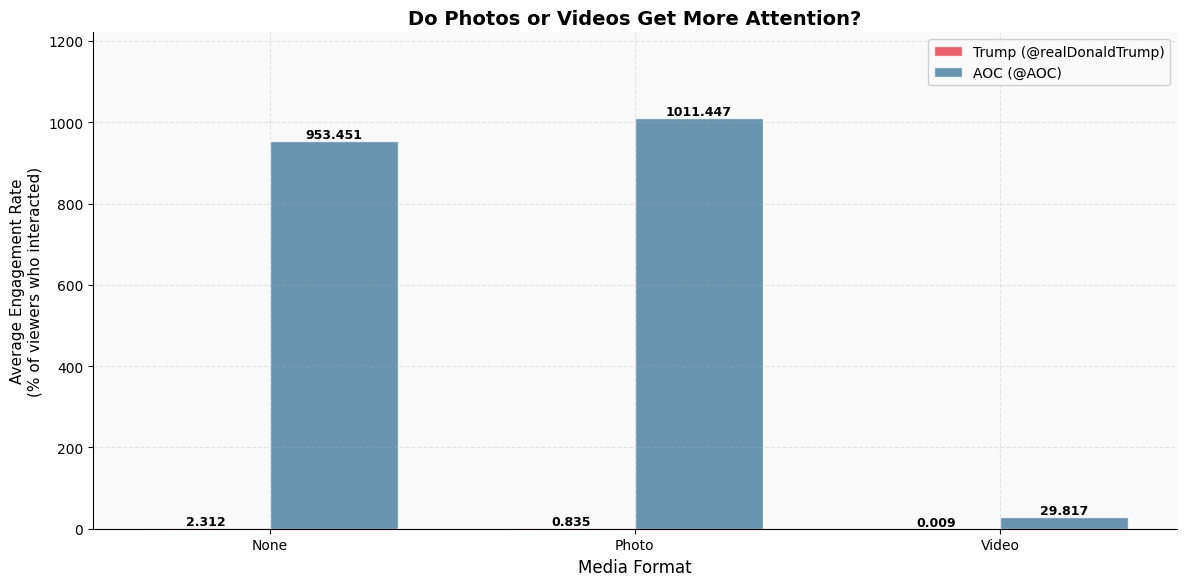


Number of tweets by media format:
media_type  none  photo  video
user                          
aoc           95      4      1
trump         41     25     34


In [10]:
# --- Do Photos or Videos Get More Attention? ---

media_types = ['none', 'photo', 'video', 'mixed']
# Only include media types that exist in the data
available_media_types = [mt for mt in media_types if mt in df['media_type'].cat.categories
                         or mt in df['media_type'].unique()]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = np.arange(len(available_media_types))
width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    means = []
    for mt in available_media_types:
        subset = df[(df['user'] == user) & (df['media_type'] == mt)]
        means.append(subset['engagement_rate'].mean() if len(subset) > 0 else 0)
    
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, means, width, label=get_user_label(user),
                  color=colors[user], alpha=0.8, edgecolor='white')
    
    # Add value labels
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Media Format', fontsize=12)
ax.set_ylabel('Average Engagement Rate\n(% of viewers who interacted)', fontsize=11)
ax.set_title('Do Photos or Videos Get More Attention?', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([mt.title() for mt in available_media_types])
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()

# Show tweet counts per media type
print("\nNumber of tweets by media format:")
print(df.groupby(['user', 'media_type'], observed=True).size().unstack(fill_value=0))

### What does this tell us?

This chart compares the average engagement rate for text-only tweets, photos, videos, and mixed media for each politician. The taller the bar, the more effective that format is at getting people to interact.

Look at whether the same format works best for both politicians, or if they have different "winning formulas." Also check the table below the chart: if one format only has a few tweets, the average might not be reliable (a single viral tweet could skew the results).

This has practical implications: if a politician's team wants to maximize engagement, they should pay attention to which formats perform best.

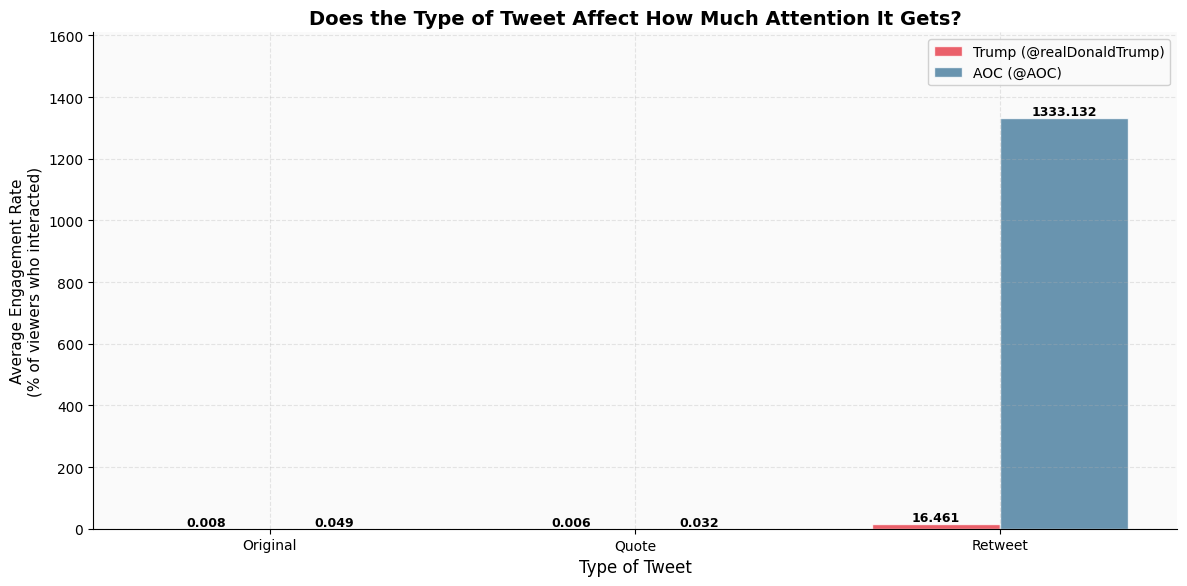


Number of tweets by type:
tweet_type  Original  Quote  Retweet
user                                
aoc                6     23       71
trump             90      3        7


In [11]:
# --- Does the Type of Tweet Matter? (Original vs Reply vs Quote vs Retweet) ---

def classify_tweet_type(row):
    if row['is_retweet']:
        return 'Retweet'
    elif row['is_quote']:
        return 'Quote'
    elif row['is_reply']:
        return 'Reply'
    else:
        return 'Original'

df['tweet_type'] = df.apply(classify_tweet_type, axis=1)
tweet_types = ['Original', 'Reply', 'Quote', 'Retweet']
# Filter to types that actually exist
available_tweet_types = [tt for tt in tweet_types if tt in df['tweet_type'].unique()]

fig, ax = plt.subplots(figsize=FIGURE_SIZE)

x = np.arange(len(available_tweet_types))
width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    means = []
    for tt in available_tweet_types:
        subset = df[(df['user'] == user) & (df['tweet_type'] == tt)]
        means.append(subset['engagement_rate'].mean() if len(subset) > 0 else 0)
    
    offset = -width/2 + i * width
    bars = ax.bar(x + offset, means, width, label=get_user_label(user),
                  color=colors[user], alpha=0.8, edgecolor='white')
    
    for bar, val in zip(bars, means):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Type of Tweet', fontsize=12)
ax.set_ylabel('Average Engagement Rate\n(% of viewers who interacted)', fontsize=11)
ax.set_title('Does the Type of Tweet Affect How Much Attention It Gets?', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(available_tweet_types)
ax.legend()
ax.set_ylim(0, ax.get_ylim()[1] * 1.15)
plt.tight_layout()
plt.show()

# Show tweet counts per type
print("\nNumber of tweets by type:")
print(df.groupby(['user', 'tweet_type'], observed=True).size().unstack(fill_value=0))

### What does this tell us?

This chart answers an important question: do original tweets, replies, quotes, or retweets generate more engagement? The answer can vary by politician.

Original tweets are new content from the politician, so they often reflect the politician's core messaging. Quotes allow them to comment on someone else's content, which can be a way to pick fights, express solidarity, or add context. Replies are conversational, and retweets are simply amplifying others.

If original tweets have the highest engagement rate, it suggests the audience values the politician's own voice above all. If quotes or replies do better, it may mean the audience enjoys the politician's interactions with others.

## 5. When Is the Best Time to Post?

Does the time of day or day of the week affect how much engagement a tweet gets? This heatmap shows the average engagement rate for every combination of hour and day.

Understanding when audiences are most receptive is crucial for political communication strategy. A well-timed tweet can reach people when they are most likely to engage, while a poorly-timed one might get buried under other content.

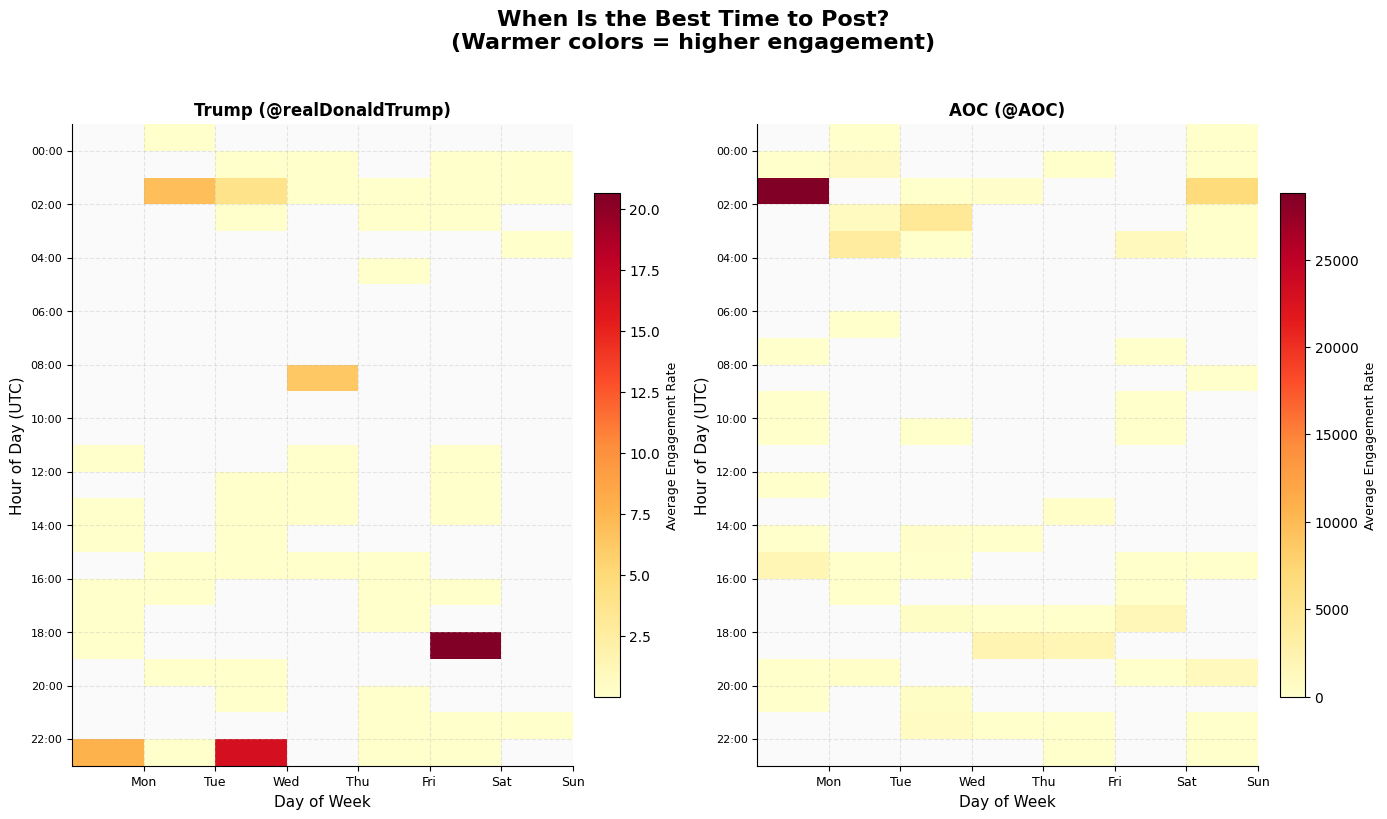

In [12]:
# --- When Is the Best Time to Post? (Engagement Heatmap) ---

day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_df = df[df['user'] == user].copy()
    
    # Create a table: average engagement rate by hour and day
    day_map = {name: i for i, name in enumerate(day_names)}
    user_df['day_num'] = user_df['day_name'].map(day_map)
    
    pivot = user_df.pivot_table(
        values='engagement_rate',
        index='hour',
        columns='day_num',
        aggfunc='mean'
    )
    
    # Ensure all hours and days are represented
    all_hours = range(24)
    all_days = range(7)
    pivot = pivot.reindex(index=all_hours, columns=all_days)
    
    # Plot heatmap (warmer colors = higher engagement)
    im = ax.pcolormesh(pivot.columns.values - 0.5,
                       pivot.index.values - 0.5,
                       pivot.values,
                       cmap='YlOrRd', shading='auto')
    
    ax.set_xticks(range(7))
    ax.set_xticklabels(day_abbr, fontsize=9)
    ax.set_yticks(range(0, 24, 2))
    ax.set_yticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], fontsize=8)
    ax.set_xlabel('Day of Week', fontsize=11)
    ax.set_ylabel('Hour of Day (UTC)', fontsize=11)
    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=12)
    ax.invert_yaxis()
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Average Engagement Rate', fontsize=9)

fig.suptitle('When Is the Best Time to Post?\n(Warmer colors = higher engagement)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### What does this tell us?

These heatmaps show the average engagement rate for each combination of hour and day of the week. **Warmer colors (orange/red) mean higher engagement**, while **lighter colors (yellow/white) mean lower engagement**. Empty (white) cells mean no tweets were posted at that time.

Look for "hot spots" -- specific times when engagement peaks. Do they coincide with typical waking hours in the US? Do weekend patterns differ from weekday patterns? If a politician gets higher engagement at unusual hours, it might mean their most engaged followers are in different time zones or have unconventional schedules.

Note that because we only have 100 tweets per politician, some time slots may have very few tweets (or none at all), so individual cells should be interpreted with caution. The overall pattern is more important than any single cell.

## 6. Bookmarks: Which Tweets Do People Save for Later?

**Bookmarks** (saves) are a special form of engagement. Unlike a quick "like" (which is public and often impulsive), bookmarking a tweet is a **private, deliberate act**. People save tweets they want to return to -- because the content is useful, important, or worth sharing later.

This makes bookmarks a window into a different kind of value. A tweet with many bookmarks may contain policy details, useful information, or arguments that people want to reference in future discussions. It signals that the content has lasting value beyond the immediate moment.

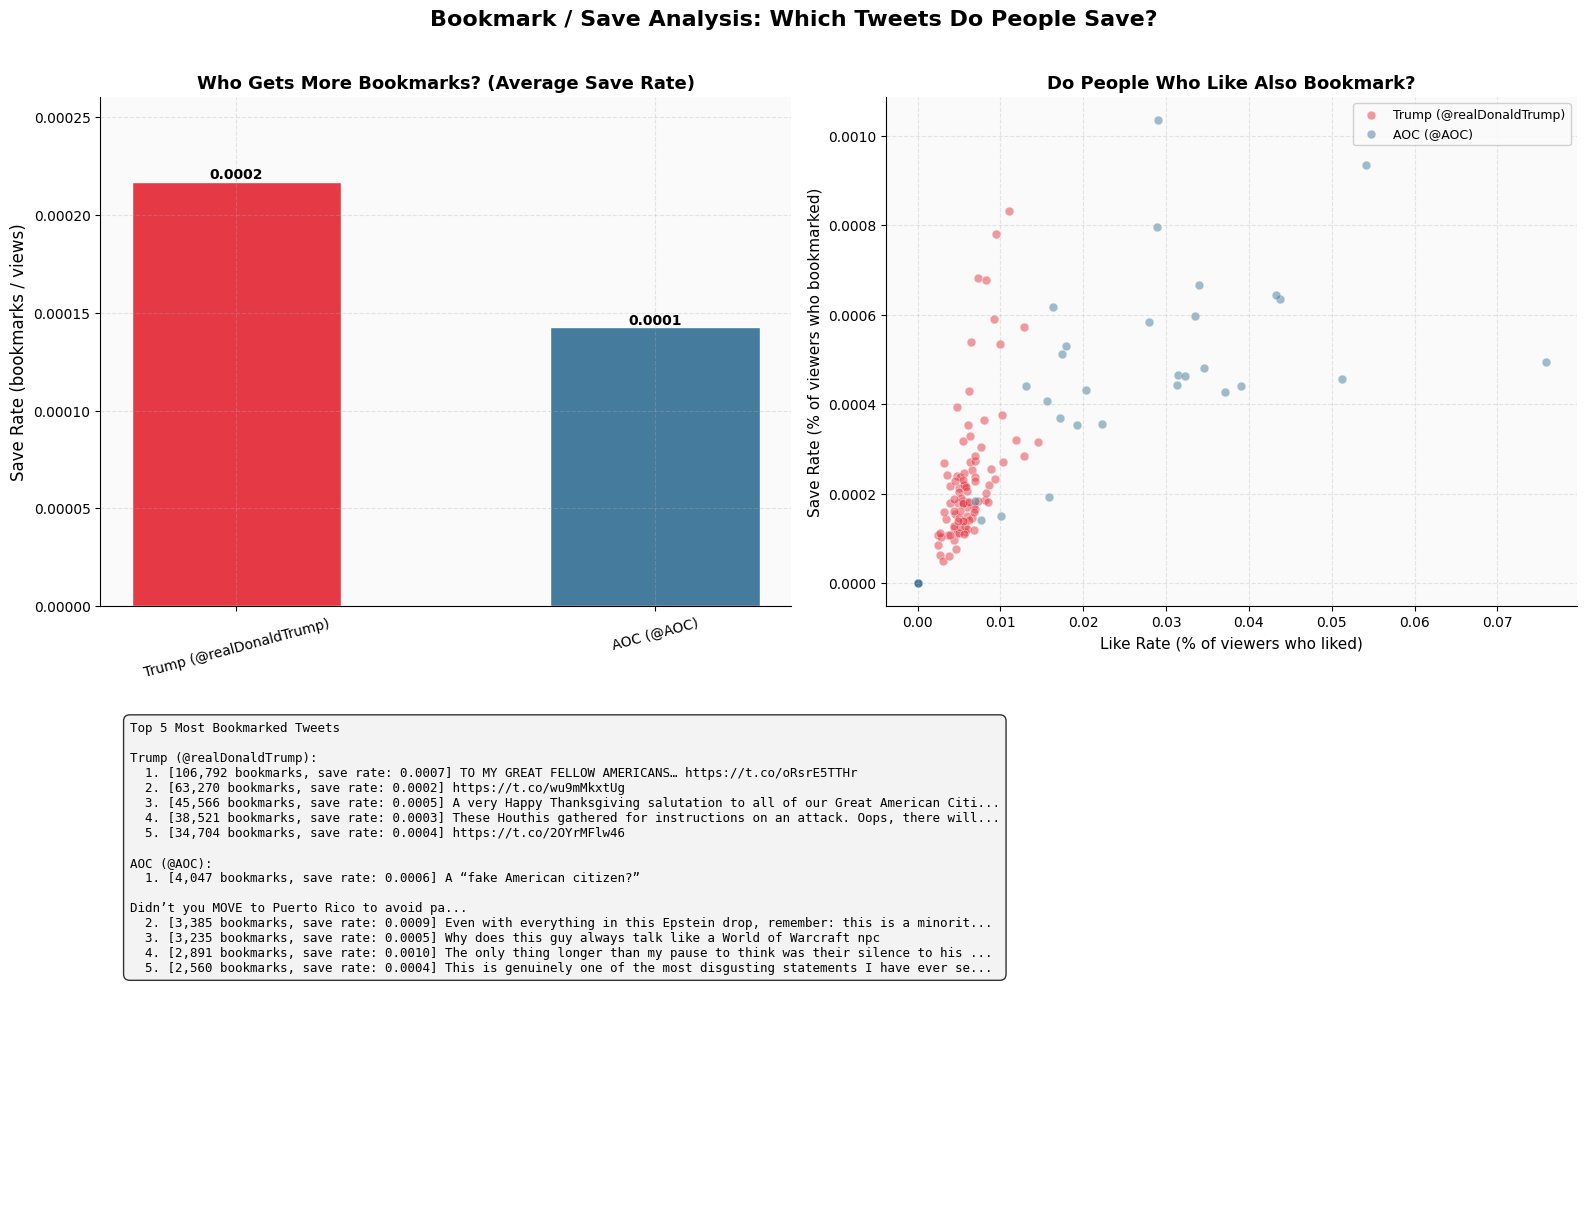

In [13]:
# --- Bookmark / Save Analysis ---

fig = plt.figure(figsize=(16, 12))

# --- Part 1: Who Gets More Bookmarks? ---
ax1 = fig.add_subplot(2, 2, 1)
users = ['trump', 'aoc']
mean_save_rates = [df[df['user'] == u]['save_rate'].mean() for u in users]
user_labels = [get_user_label(u) for u in users]

bars = ax1.bar(user_labels, mean_save_rates,
               color=[colors[u] for u in users], width=0.5, edgecolor='white')

for bar, val in zip(bars, mean_save_rates):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{val:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_title('Who Gets More Bookmarks? (Average Save Rate)', fontweight='bold', fontsize=13)
ax1.set_ylabel('Save Rate (bookmarks / views)')
ax1.set_ylim(0, max(mean_save_rates) * 1.2 if max(mean_save_rates) > 0 else 0.001)
ax1.tick_params(axis='x', rotation=15)

# --- Part 2: Do People Who Like Also Bookmark? ---
ax2 = fig.add_subplot(2, 2, 2)

for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]
    ax2.scatter(user_data['like_rate'], user_data['save_rate'],
               color=colors[user], alpha=0.5, s=40,
               label=get_user_label(user), edgecolors='white', linewidth=0.5)

ax2.set_xlabel('Like Rate (% of viewers who liked)', fontsize=11)
ax2.set_ylabel('Save Rate (% of viewers who bookmarked)', fontsize=11)
ax2.set_title('Do People Who Like Also Bookmark?', fontweight='bold', fontsize=13)
ax2.legend(fontsize=9)

# --- Part 3: The Most Bookmarked Tweets ---
ax3 = fig.add_subplot(2, 1, 2)
ax3.axis('off')

top_bookmarked_text = []
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user].nlargest(5, 'bookmark_count')
    label = get_user_label(user)
    top_bookmarked_text.append(f"\n{label}:")
    for rank, (_, row) in enumerate(user_df.iterrows(), 1):
        text_preview = row['text'][:70] + '...' if len(str(row['text'])) > 70 else row['text']
        bookmarks = int(row['bookmark_count'])
        saves = row['save_rate']
        top_bookmarked_text.append(
            f"  {rank}. [{bookmarks:,} bookmarks, save rate: {saves:.4f}] {text_preview}"
        )

full_text = "Top 5 Most Bookmarked Tweets\n" + "\n".join(top_bookmarked_text)
ax3.text(0.02, 0.95, full_text, transform=ax3.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f0f0', alpha=0.8))

fig.suptitle('Bookmark / Save Analysis: Which Tweets Do People Save?',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### What does this tell us?

Three things to notice:

1. **Average save rate** (top left): Which politician's content do people save more often? A higher save rate suggests the content has lasting utility -- people want to come back to it.

2. **Likes vs. bookmarks** (top right): Each dot is a tweet. If dots form an upward line from left to right, it means tweets that get more likes also tend to get more bookmarks. If the dots are scattered, likes and bookmarks measure different things.

3. **Most bookmarked tweets** (bottom): Read the actual text of the most-saved tweets. What kind of content is it? Policy details? Powerful statements? News reactions? The content people choose to save reveals what they consider reference-worthy, not just entertaining.

## 7. Key Takeaways: What We Learned About Engagement

After analyzing how audiences respond to Trump and AOC's tweets, here are the main findings:

**Who gets more total attention?**
- Trump, as a former president with a massive following, generates significantly higher raw numbers in views, likes, and retweets. This reflects the enormous scale of his platform presence and the intensity of public attention around his posts.
- However, raw totals alone do not tell the full story. The size of the audience matters: a politician who reaches 50 million people per tweet will naturally accumulate more likes than one who reaches 5 million, even if both are equally compelling.

**Who connects more effectively with their audience?**
- The engagement rate analysis reveals the quality of the connection between politician and audience, independent of raw follower count. A higher engagement rate means a greater proportion of viewers actively respond to the content.
- Differences in engagement rate point to differences in how each politician's audience relates to them: passive consumption vs. active participation.

**What makes a tweet go viral?**
- The most viral tweets for each politician tend to share certain characteristics: they address emotionally charged topics, use strong language, and speak to the core concerns of their respective audiences.
- Virality is not random -- it reflects the alignment between a message and its audience's values and emotions.

**Does format matter?**
- The relationship between media format (text, photo, video) and engagement varies between the two politicians. What works for one audience may not work for another, suggesting that optimal communication strategies are audience-specific.
- Tweet type (original vs. quote vs. reply) also affects engagement differently, reflecting each politician's unique communication style and their audience's expectations.

**When should they post?**
- The engagement heatmaps reveal that timing matters, but the optimal posting times differ between the two politicians. This likely reflects the different demographics and habits of their respective audiences.
- Weekend vs. weekday differences also emerge, suggesting that the political attention cycle does not take days off on social media.

**What about bookmarks?**
- Bookmark behavior reveals a dimension of engagement that likes and retweets miss. People save content they find genuinely useful or important, not just entertaining or provocative.
- The types of tweets that get bookmarked tell us about the informational and reference value of each politician's content, beyond its immediate emotional impact.

---

### Historical Perspective

These engagement metrics represent something genuinely new in the history of political communication. For the first time, we can measure -- in real time and at scale -- how audiences receive political messages. Every like is a micro-endorsement. Every retweet is an act of amplification. Every reply is a piece of public discourse. Together, they form a rich archive of how democratic publics engage with their representatives in the digital age.

### What Comes Next

In the next notebooks, we will move beyond *how much* attention each politician gets and examine *what* they actually say (content and language analysis), *who* they interact with (network analysis), and what it all means for understanding digital political communication.

---

*Note: This analysis is based on a sample of 100 tweets per politician. While this provides meaningful insights into recent patterns, it represents a snapshot rather than a comprehensive history. As with any historical source, the sample should be interpreted with awareness of its limitations.*